# Reflectance Exercise 2 — white-reference baseline and channel offset

Plot repeated stationary readings, estimate a separate white-reference baseline for each sensor, and compare variation within and between placements.

Start with the supplied synthetic example so that every cell runs before you have collected data. The example demonstrates the analysis route; it is not evidence about your robot and its values are not coursework answers. You do not need to understand or edit the example-generation cell.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(2026)


## 1. Use the example or your own data

Leave `USE_EXAMPLE_DATA` set to `True` for your first run. To use your measurements, upload the CSV, change it to `False`, and enter its filename. This is the main data-loading setting you need to edit.

Expected raw CSV columns: `test_name`, `trial_num`, `sample_num`, `sample_time`, `sensor_num`, and `sensor_reading`.

`sample_time` is the robot timestamp in microseconds and `sensor_num` is the array index 0–4.


In [2]:
USE_EXAMPLE_DATA = True
CSV_FILENAME = "reflectance_exercise02.csv"

print("Using:", "synthetic example" if USE_EXAMPLE_DATA else CSV_FILENAME)


Using: synthetic example


## 2. Create the small synthetic example

The example contains three placements over white and three over an off-white check surface. Do not edit this cell.


In [3]:
rows = []
channel_centres = [235, 270, 248, 285, 255]
for test_name, surface_shift in [
    ("offsetTest_white", 0), ("offsetTest_offwhite", 75)
]:
    for trial_num, placement_shift in [(1, 0), (2, 7), (3, -4)]:
        for sample_num in range(1, 31):
            sample_time = trial_num * 1_000_000 + sample_num * 10_000
            for sensor_num, centre in enumerate(channel_centres):
                rows.append({
                    "test_name": test_name, "trial_num": trial_num,
                    "sample_num": sample_num, "sample_time": sample_time,
                    "sensor_num": sensor_num,
                    "sensor_reading": centre + surface_shift
                    + placement_shift + rng.normal(0, 5),
                })
example_data = pd.DataFrame(rows)


## 3. Load and preview the selected data

This is where an uploaded CSV enters the notebook. Check that the column names, units and labels match the exercise before continuing.


In [4]:
if USE_EXAMPLE_DATA:
    data = example_data.copy()
else:
    data = pd.read_csv(CSV_FILENAME)

data.head()


,test_name,trial_num,sample_num,sample_time,sensor_num,sensor_reading
0,offsetTest_white,1,1,1010000,0,231.034388
1,offsetTest_white,1,1,1010000,1,271.202856
2,offsetTest_white,1,1,1010000,2,238.518368
3,offsetTest_white,1,1,1010000,3,291.978859
4,offsetTest_white,1,1,1010000,4,258.191474


## 4. Select the two recorded conditions

Use the labels written into your CSV. The white rows establish the baseline; the off-white rows provide a separate check.


In [5]:
WHITE_TEST_NAME = "offsetTest_white"
CHECK_TEST_NAME = "offsetTest_offwhite"
SELECTED_SENSOR = 0
SELECTED_TRIAL = 1

white_data = data.loc[data["test_name"] == WHITE_TEST_NAME].copy()
check_data = data.loc[data["test_name"] == CHECK_TEST_NAME].copy()


## 5. Plot readings in time order

A boxplot hides time order, so first inspect one complete stationary trial for drift, jumps or repeated cached values.


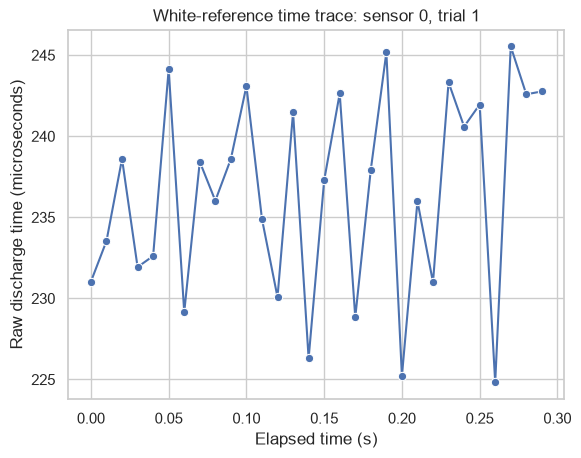

In [6]:
time_trace = white_data.loc[
    (white_data["sensor_num"] == SELECTED_SENSOR)
    & (white_data["trial_num"] == SELECTED_TRIAL)
].copy()
time_trace["elapsed_time_s"] = (
    time_trace["sample_time"] - time_trace["sample_time"].min()
) / 1_000_000

sns.lineplot(data=time_trace, x="elapsed_time_s", y="sensor_reading", marker="o")
plt.title(f"White-reference time trace: sensor {SELECTED_SENSOR}, trial {SELECTED_TRIAL}")
plt.xlabel("Elapsed time (s)")
plt.ylabel("Raw discharge time (microseconds)")
plt.show()


## 6. Compare sensors and placements

Colour distinguishes placements. Compare the shift between boxes with the spread inside each box.


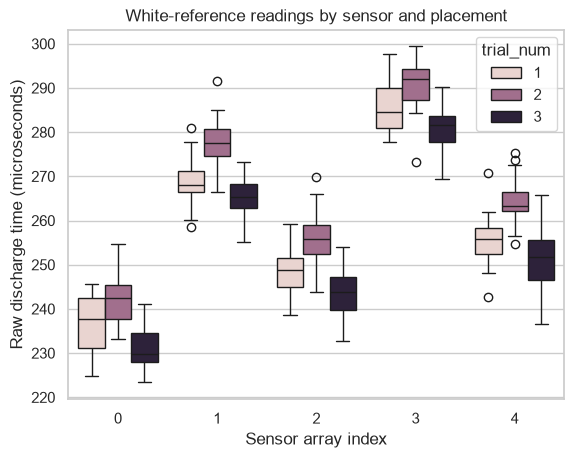

In [7]:
sns.boxplot(data=white_data, x="sensor_num", y="sensor_reading", hue="trial_num")
plt.title("White-reference readings by sensor and placement")
plt.xlabel("Sensor array index")
plt.ylabel("Raw discharge time (microseconds)")
plt.show()


## 7. Calculate the five baselines

`groupby` collects rows with the same sensor and trial labels. The first table preserves placement results; the second gives one operational white reference per sensor.


In [8]:
placement_summary = (
    white_data.groupby(["sensor_num", "trial_num"], as_index=False)
    .agg(samples=("sensor_reading", "size"),
         mean_us=("sensor_reading", "mean"),
         median_us=("sensor_reading", "median"),
         variance_us2=("sensor_reading", "var"),
         sd_us=("sensor_reading", "std"))
)
placement_summary


,sensor_num,trial_num,samples,mean_us,median_us,variance_us2,sd_us
0,0,1,30,236.515244,237.607683,39.144884,6.256587
1,0,2,30,241.898565,242.398132,26.837494,5.180492
2,0,3,30,231.475514,229.853934,25.042463,5.004245
3,1,1,30,268.818851,268.034733,23.901822,4.888949
4,1,2,30,277.622152,277.520022,27.602031,5.253763
5,1,3,30,265.330625,265.366172,16.912746,4.112511
6,2,1,30,248.683062,248.913493,23.281696,4.825111
7,2,2,30,255.809192,255.780890,31.004328,5.568153
8,2,3,30,243.669746,243.878680,28.750393,5.361939
9,3,1,30,285.289989,284.460102,27.178562,5.213306


In [9]:
channel_reference = (
    placement_summary.groupby("sensor_num", as_index=False)
    .agg(white_reference_us=("median_us", "median"),
         between_placement_sd_us=("median_us", "std"),
         typical_within_sd_us=("sd_us", "median"))
)
common_reference_us = channel_reference["white_reference_us"].median()
channel_reference["offset_from_common_reference_us"] = (
    channel_reference["white_reference_us"] - common_reference_us
)
channel_reference


,sensor_num,white_reference_us,between_placement_sd_us,typical_within_sd_us,offset_from_common_reference_us
0,0,237.607683,6.330165,5.180492,-18.218734
1,1,268.034733,6.387592,4.888949,12.208316
2,2,248.913493,5.974572,5.361939,-6.912924
3,3,284.460102,5.426061,5.213306,28.633684
4,4,255.826417,5.852788,5.185191,0.000000


## 8. Check the baselines against off-white

Each off-white reading is compared with its own sensor's white reference. This does not overwrite or pool the raw measurements.


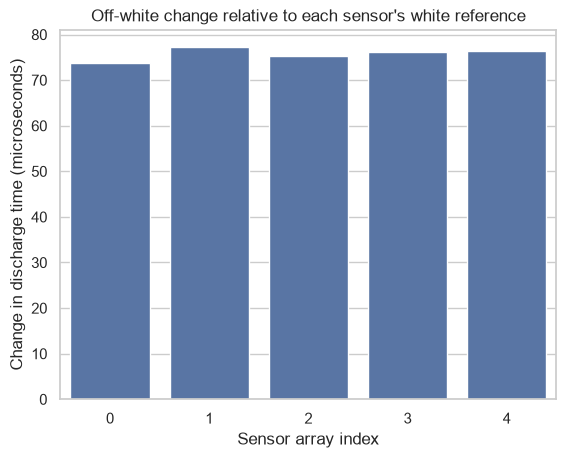

,sensor_num,offwhite_median_us,white_reference_us,between_placement_sd_us,typical_within_sd_us,offset_from_common_reference_us,white_relative_change_us
0,0,311.359701,237.607683,6.330165,5.180492,-18.218734,73.752018
1,1,345.241076,268.034733,6.387592,4.888949,12.208316,77.206343
2,2,324.158731,248.913493,5.974572,5.361939,-6.912924,75.245238
3,3,360.570326,284.460102,5.426061,5.213306,28.633684,76.110225
4,4,332.143551,255.826417,5.852788,5.185191,0.000000,76.317134


In [10]:
if check_data.empty:
    baseline_check = pd.DataFrame()
    print(f"No rows labelled {CHECK_TEST_NAME!r} yet.")
else:
    check_summary = (
        check_data.groupby("sensor_num", as_index=False)
        .agg(offwhite_median_us=("sensor_reading", "median"))
    )
    baseline_check = check_summary.merge(
        channel_reference, on="sensor_num", validate="one_to_one"
    )
    baseline_check["white_relative_change_us"] = (
        baseline_check["offwhite_median_us"]
        - baseline_check["white_reference_us"]
    )
    sns.barplot(data=baseline_check, x="sensor_num", y="white_relative_change_us")
    plt.title("Off-white change relative to each sensor's white reference")
    plt.xlabel("Sensor array index")
    plt.ylabel("Change in discharge time (microseconds)")
    plt.show()
baseline_check


## What to notice

- Does the time trace remain stationary enough to summarise?
- Are channel differences large relative to placement variation?
- Do all five sensors respond similarly to the off-white change?
- These are measured reference values, not hidden middleware offsets.
